# Factors That Affect the Accuracy of Non-Neural ML Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, r2_score, mean_squared_error, mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

### Load data

In [2]:
df = pd.read_csv('Ds_salaries.csv')
print('Shape:', df.shape)
df.head()

Shape: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
# Check for missing values
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

### Clean data

Keep only 2021-2023 and full-time employees.
Rename columns to be easier to read.

In [4]:
# Pick columns
df = df[['work_year', 'experience_level', 'employment_type', 'job_title',
         'company_location', 'company_size', 'employee_residence',
         'salary_in_usd', 'remote_ratio']]

# Filter years and employment type
df = df[df['work_year'].isin([2021, 2022, 2023])]
df = df[df['employment_type'] == 'FT']

# Rename
df = df.rename(columns={
    'work_year': 'Work Year',
    'experience_level': 'Experience Level',
    'employment_type': 'Employment Type',
    'job_title': 'Job Title',
    'company_location': 'Company Location',
    'company_size': 'Company Size',
    'employee_residence': 'Employee Residence',
    'salary_in_usd': 'Salary in USD',
    'remote_ratio': 'Remote Ratio',
})

# Fix one duplicate job title (ML Engineer = Machine Learning Engineer)
df['Job Title'] = df['Job Title'].replace({'ML Engineer': 'Machine Learning Engineer'})

# Rename experience level names
df['Experience Level'] = df['Experience Level'].replace({
    'EN': 'Entry', 'MI': 'Middle', 'SE': 'Senior', 'EX': 'Expert'
})

df = df.reset_index(drop=True)
print('After cleaning:', df.shape)
df.head()

After cleaning: (3646, 9)


,Work Year,Experience Level,Employment Type,Job Title,Company Location,Company Size,Employee Residence,Salary in USD,Remote Ratio
0,2023,Senior,FT,Principal Data Scientist,ES,L,ES,85847,100
1,2023,Senior,FT,Data Scientist,CA,M,CA,175000,100
2,2023,Senior,FT,Data Scientist,CA,M,CA,120000,100
3,2023,Senior,FT,Applied Scientist,US,L,US,222200,0
4,2023,Senior,FT,Applied Scientist,US,L,US,136000,0


### Look at the data

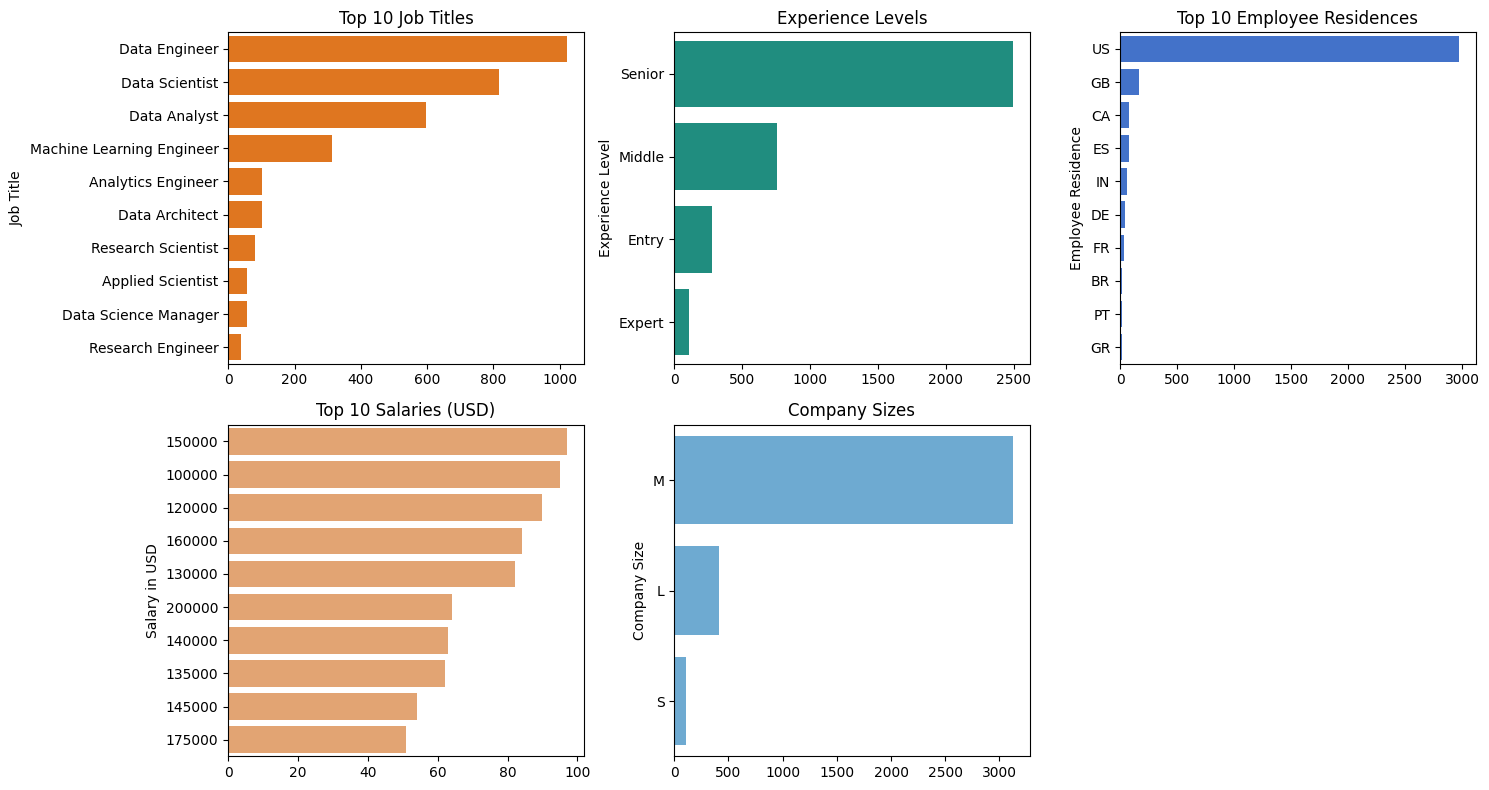

In [5]:
# Five quick distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top 10 job titles
top_jobs = df['Job Title'].value_counts().head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, ax=axes[0, 0], color='#FF7300')
axes[0, 0].set_title('Top 10 Job Titles')

# Experience levels
exp = df['Experience Level'].value_counts()
sns.barplot(x=exp.values, y=exp.index, ax=axes[0, 1], color='#0E9F8C')
axes[0, 1].set_title('Experience Levels')

# Top 10 nationalities
top_res = df['Employee Residence'].value_counts().head(10)
sns.barplot(x=top_res.values, y=top_res.index, ax=axes[0, 2], color='#2D6CDF')
axes[0, 2].set_title('Top 10 Employee Residences')

# Top 10 salaries by count
top_salary = df['Salary in USD'].value_counts().head(10)
sns.barplot(x=top_salary.values, y=top_salary.index.astype(str),
            ax=axes[1, 0], color='#F4A261', orient='h')
axes[1, 0].set_title('Top 10 Salaries (USD)')

# Company sizes
size = df['Company Size'].value_counts()
sns.barplot(x=size.values, y=size.index, ax=axes[1, 1], color='#5DADE2')
axes[1, 1].set_title('Company Sizes')

# Hide the last empty spot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# How many unique values in each target column, and how big is the majority class?
for col in ['Salary in USD', 'Job Title', 'Employee Residence',
            'Experience Level', 'Company Size']:
    n = df[col].nunique()
    top = df[col].value_counts().iloc[0]
    pct = top / len(df) * 100
    print(f'{col:<20} -> {n:>4} unique, biggest class = {pct:.1f}%')

Salary in USD        ->  977 unique, biggest class = 2.7%
Job Title            ->   90 unique, biggest class = 28.0%
Employee Residence   ->   70 unique, biggest class = 81.5%
Experience Level     ->    4 unique, biggest class = 68.4%
Company Size         ->    3 unique, biggest class = 85.7%


### Label encoding

In [7]:
# Encode each categorical column
for col in ['Experience Level', 'Job Title', 'Employment Type',
            'Company Location', 'Company Size', 'Employee Residence',
            'Remote Ratio']:
    le = LabelEncoder()
    df[col + ' Label'] = le.fit_transform(df[col])

df.head()

,Work Year,Experience Level,Employment Type,Job Title,Company Location,Company Size,Employee Residence,Salary in USD,Remote Ratio,Experience Level Label,Job Title Label,Employment Type Label,Company Location Label,Company Size Label,Employee Residence Label,Remote Ratio Label
0,2023,Senior,FT,Principal Data Scientist,ES,L,ES,85847,100,3,83,0,22,0,22,2
1,2023,Senior,FT,Data Scientist,CA,M,CA,175000,100,3,47,0,10,1,11,2
2,2023,Senior,FT,Data Scientist,CA,M,CA,120000,100,3,47,0,10,1,11,2
3,2023,Senior,FT,Applied Scientist,US,L,US,222200,0,3,8,0,64,0,67,0
4,2023,Senior,FT,Applied Scientist,US,L,US,136000,0,3,8,0,64,0,67,0


### Correlation heatmap

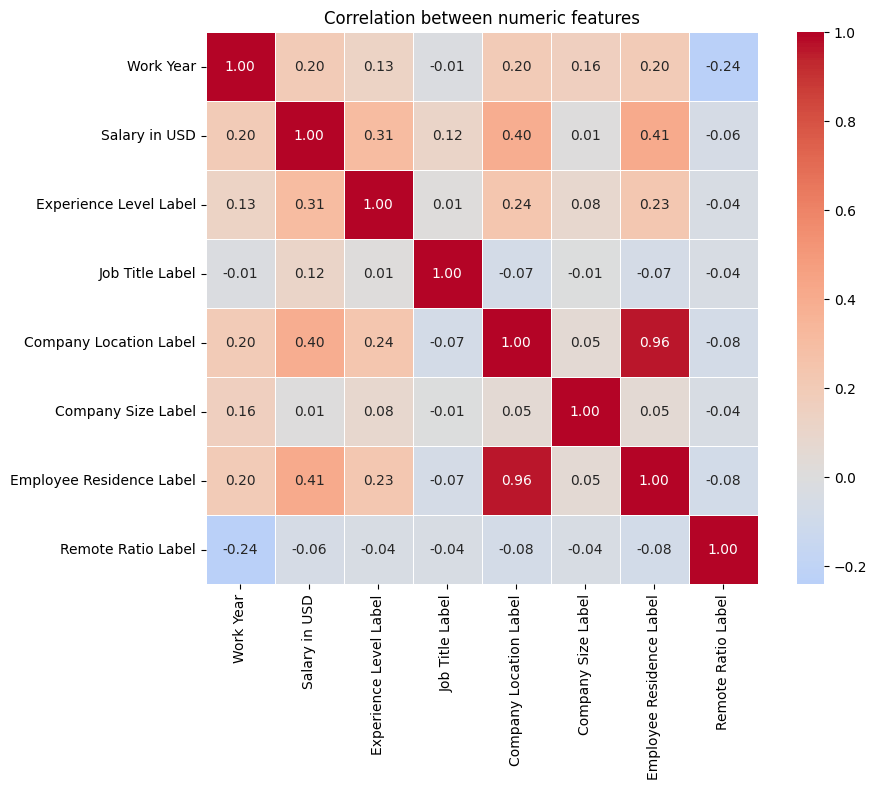

In [8]:
numeric_cols = ['Work Year', 'Salary in USD',
                'Experience Level Label', 'Job Title Label',
                'Company Location Label', 'Company Size Label',
                'Employee Residence Label', 'Remote Ratio Label']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

### Check the data leakage problem

In [9]:
same = (df['Company Location'] == df['Employee Residence']).mean() * 100
print(f'Company Location matches Employee Residence in {same:.1f}% of rows')
print('-> Drop Company Location when predicting Employee Residence.')

Company Location matches Employee Residence in 98.0% of rows
-> Drop Company Location when predicting Employee Residence.


### Run all the models

In [10]:
# Choose columns as features
all_features = ['Work Year', 'Salary in USD',
                'Experience Level Label', 'Job Title Label',
                'Company Location Label', 'Company Size Label',
                'Employee Residence Label', 'Remote Ratio Label']


def run_models(target_col, drop_cols):
    # Features = everything except the target and any columns we want to exclude
    features = [c for c in all_features if c not in drop_cols]

    x = df[features]
    y = df[target_col]

    # Same 60/40 split for every model
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.4, random_state=25)

    results = []

    most_common = y_train.value_counts().idxmax()
    baseline_acc = (y_test == most_common).mean()
    results.append({'Model': 'Most common class', 'Score': baseline_acc})

    # Linear Regression
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    pred = lr.predict(x_test)
    lr_score = r2_score(y_test, pred)
    results.append({'Model': 'Linear Regression', 'Score': lr_score})

    # The 5 classifiers
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'KNN':                 KNeighborsClassifier(n_neighbors=5),
        'Decision Tree':       DecisionTreeClassifier(random_state=25),
        'Random Forest':       RandomForestClassifier(random_state=25),
        'Naive Bayes':         GaussianNB(),
    }

    for name, model in classifiers.items():
        model.fit(x_train, y_train)
        pred = model.predict(x_test)
        acc = accuracy_score(y_test, pred)
        results.append({'Model': name, 'Score': acc})

    return pd.DataFrame(results).set_index('Model')

In [11]:
### Run all the models on each target

In [12]:
exp_results = run_models('Experience Level Label', ['Experience Level Label'])
print('Experience Level (4 classes)')
exp_results.round(3)

Experience Level (4 classes)


,Score
Model,
Most common class,0.692
Linear Regression,0.126
Logistic Regression,0.710
KNN,0.705
Decision Tree,0.700
Random Forest,0.740
Naive Bayes,0.700


In [13]:
size_results = run_models('Company Size Label', ['Company Size Label'])
print('Company Size (3 classes)')
size_results.round(3)

Company Size (3 classes)


,Score
Model,
Most common class,0.851
Linear Regression,0.033
Logistic Regression,0.851
KNN,0.847
Decision Tree,0.853
Random Forest,0.886
Naive Bayes,0.783


In [14]:
job_results = run_models('Job Title Label', ['Job Title Label'])
print('Job Title (90 classes)')
job_results.round(3)

Job Title (90 classes)


,Score
Model,
Most common class,0.278
Linear Regression,0.036
Logistic Regression,0.284
KNN,0.356
Decision Tree,0.378
Random Forest,0.382
Naive Bayes,0.029


In [15]:
# Drop Company Location too since it is almost the same column as Employee Residence
res_results = run_models('Employee Residence Label',
                         ['Employee Residence Label', 'Company Location Label'])
print('Employee Residence (70 classes, Company Location dropped)')
res_results.round(3)

Employee Residence (70 classes, Company Location dropped)


,Score
Model,
Most common class,0.820
Linear Regression,0.226
Logistic Regression,0.833
KNN,0.829
Decision Tree,0.808
Random Forest,0.839
Naive Bayes,0.822


In [16]:
# Salary as a target
salary_results = run_models('Salary in USD', ['Salary in USD'])
print('Salary in USD (977 classes)')
salary_results.round(3)

Salary in USD (977 classes)


,Score
Model,
Most common class,0.023
Linear Regression,0.271
Logistic Regression,0.021
KNN,0.027
Decision Tree,0.053
Random Forest,0.055
Naive Bayes,0.024


In [17]:
# Score table - models on rows, targets on columns
# Ordered from lowest cardinality (Company Size, 3) to highest (Salary, 977)
score_table = pd.DataFrame({
    'Company Size (3)':         size_results['Score'],
    'Experience Level (4)':     exp_results['Score'],
    'Employee Residence (70)':  res_results['Score'],
    'Job Title (90)':           job_results['Score'],
    'Salary in USD (977)':      salary_results['Score'],
}) * 100

print('SCORE (%) - sorted by number of classes')
print('(Accuracy for classifiers, R² for Linear Regression)')
score_table.round(1)

SCORE (%) - sorted by number of classes
(Accuracy for classifiers, R² for Linear Regression)


,Company Size (3),Experience Level (4),Employee Residence (70),Job Title (90),Salary in USD (977)
Model,,,,,
Most common class,85.1,69.2,82.0,27.8,2.3
Linear Regression,3.3,12.6,22.6,3.6,27.1
Logistic Regression,85.1,71.0,83.3,28.4,2.1
KNN,84.7,70.5,82.9,35.6,2.7
Decision Tree,85.3,70.0,80.8,37.8,5.3
Random Forest,88.6,74.0,83.9,38.2,5.5
Naive Bayes,78.3,70.0,82.2,2.9,2.4


### All 6 models vs. the baseline

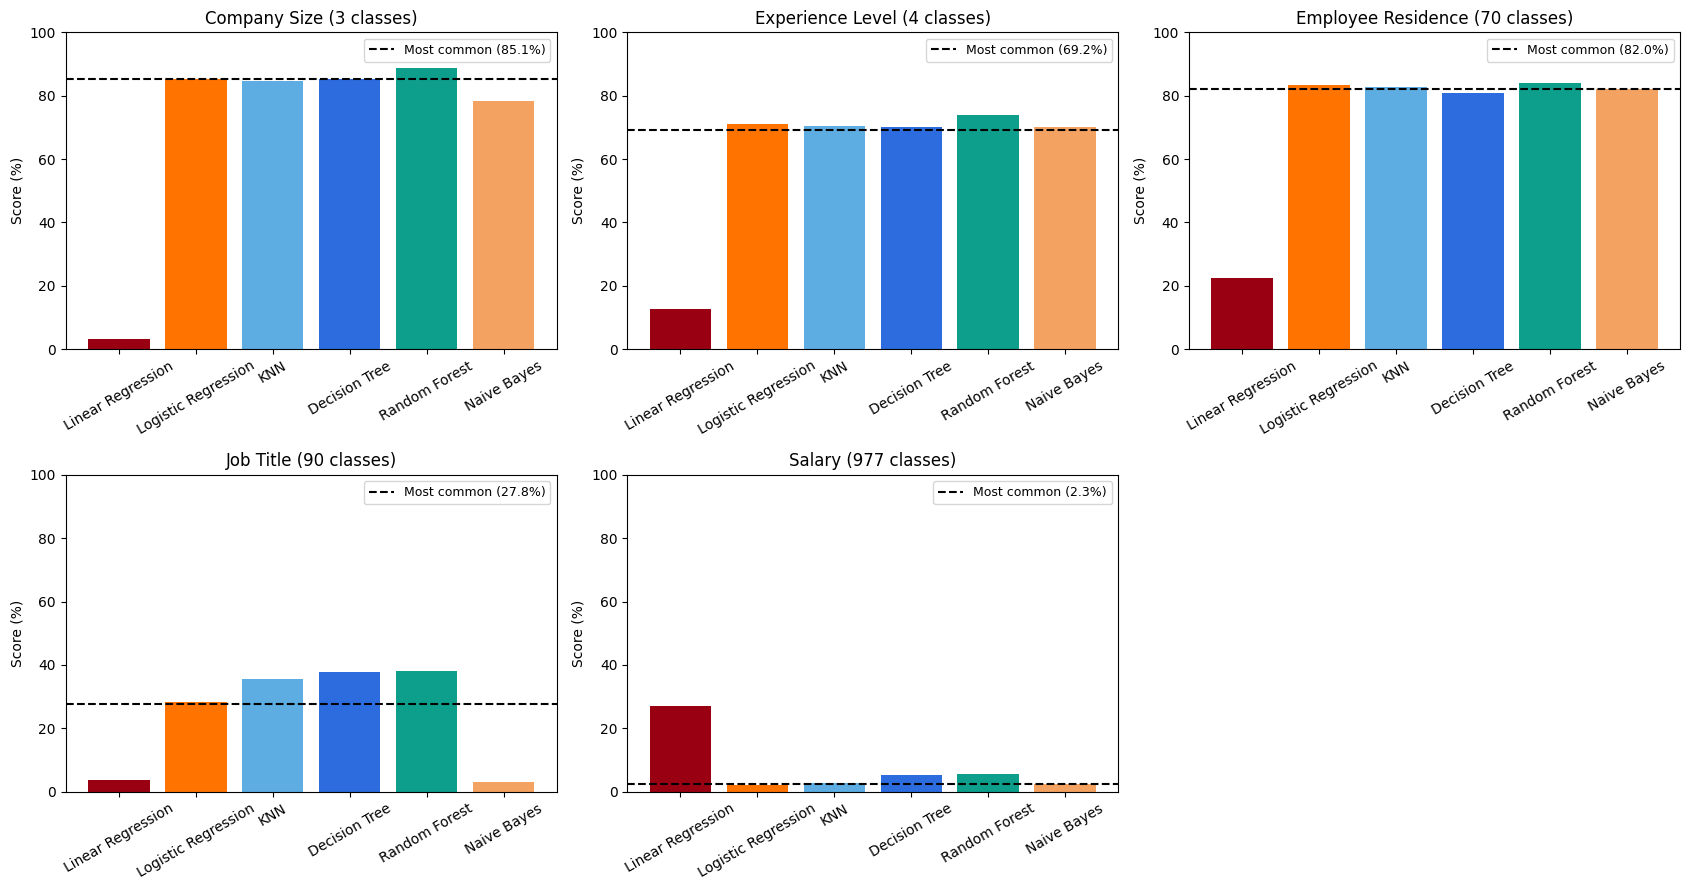

In [18]:
all_models = ['Linear Regression', 'Logistic Regression', 'KNN',
              'Decision Tree', 'Random Forest', 'Naive Bayes']
colors = ['#990011', '#FF7300', '#5DADE2', '#2D6CDF', '#0E9F8C', '#F4A261']

# 2 rows by 3 columns, sorted by number of classes
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

target_results = [
    ('Company Size (3 classes)',         size_results),
    ('Experience Level (4 classes)',     exp_results),
    ('Employee Residence (70 classes)',  res_results),
    ('Job Title (90 classes)',           job_results),
    ('Salary (977 classes)',             salary_results),
]

for ax, (title, results) in zip(axes.flat, target_results):
    baseline_score = results.loc['Most common class', 'Score'] * 100
    scores = results.loc[all_models, 'Score'] * 100

    ax.bar(all_models, scores, color=colors)
    ax.axhline(baseline_score, color='black', linestyle='--', linewidth=1.5,
               label=f'Most common ({baseline_score:.1f}%)')
    ax.set_title(title)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

# Hide the empty 6th subplot
axes.flat[5].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
### Confusion matrix - Random Forest on Experience Level

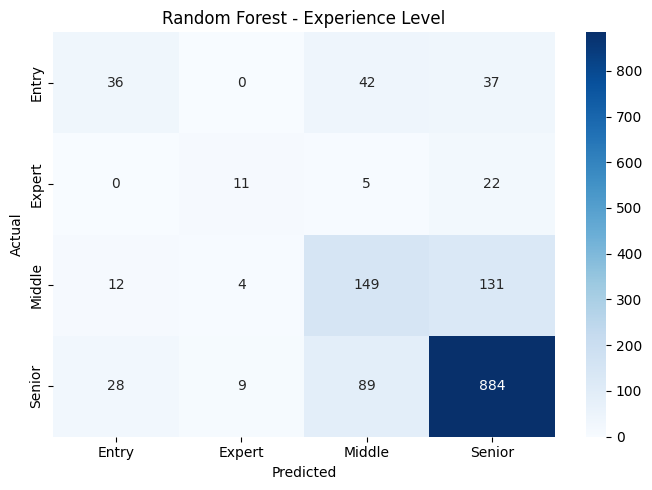

In [20]:
from sklearn.metrics import confusion_matrix

# Rerun Random Forest on Experience Level to get the predictions back
features = [c for c in all_features if c != 'Experience Level Label']
x = df[features]
y = df['Experience Level Label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.4, random_state=25)

rf = RandomForestClassifier(random_state=25)
rf.fit(x_train, y_train)
pred = rf.predict(x_test)

# Get the readable class names in label order
labels = sorted(df['Experience Level Label'].unique())
label_names = [df.loc[df['Experience Level Label'] == lbl, 'Experience Level'].iloc[0]
               for lbl in labels]

cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Random Forest - Experience Level')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()